In [94]:
import dask.dataframe as dd
import pandas as pd
data = dd.read_csv('playstore_cleaned_data.csv')
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content_Rating,Genres,Last_Updated,Current_Ver,Android_Ver,Pri_Genres,Sec_Genres,Version_begin,Version_end,Current_Ver_updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000.0,Free,0.0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up,Art & Design,Art & Design,4.0.3,up,1.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up,Art & Design,Pretend Play,4.0.3,up,2.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000.0,Free,0.0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up,Art & Design,Art & Design,4.0.3,up,1.2
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000.0,Free,0.0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up,Art & Design,Art & Design,4.2,up,Varies with device
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000.0,Free,0.0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up,Art & Design,Creativity,4.4,up,1.1


In [95]:
# 1a. Kategori aplikasi dengan jumlah unduhan tertinggi
kategori_tertinggi = data.groupby('Category')['Installs'].sum().compute()
kategori_tertinggi = kategori_tertinggi.sort_values(ascending=False).reset_index().head(5)
pd.options.display.float_format = '{:,.0f}'.format
print("Kategori aplikasi dengan unduhan tertinggi:")
print(kategori_tertinggi)
pd.reset_option('display.float_format')

Kategori aplikasi dengan unduhan tertinggi:
        Category       Installs
0           GAME 13,878,924,415
1  COMMUNICATION 11,038,276,251
2          TOOLS  8,001,771,915
3   PRODUCTIVITY  5,793,091,369
4         SOCIAL  5,487,867,902


In [96]:
# 1b. 10 produk dengan rating tertinggi

In [97]:
#  1c. Korelasi dari analisis data diatas

In [98]:
# 2. Perbandingan Price (paid dan free) aplikasi
perbandingan_harga = (data[data['Type'].isin(['Free', 'Paid'])].groupby('Type')['Rating'].agg(['mean', 'count'])
                    .reset_index().rename(columns={'mean': 'Rata-rata Rating', 'count': 'Jumlah Aplikasi'}).compute())
perbandingan_harga['Rata-rata Rating'] = perbandingan_harga['Rata-rata Rating'].round(2)
perbandingan_harga['Persentase (%)'] = (perbandingan_harga['Jumlah Aplikasi'] / perbandingan_harga['Jumlah Aplikasi'].sum() * 100).round(2)
print("Perbandingan price (paid dan free) aplikasi:")
print(perbandingan_harga)

Perbandingan price (paid dan free) aplikasi:
   Type  Rata-rata Rating  Jumlah Aplikasi  Persentase (%)
0  Free              4.17             8902           92.17
1  Paid              4.25              756            7.83


In [99]:
# 3a. Genre dengan Rating tertinggi
genre_rating = (data.groupby('Genres')['Rating'].mean().reset_index().compute())
genre_rating['Rating'] = genre_rating['Rating'].round(2)
genre_rating_tertinggi = genre_rating.sort_values(by='Rating', ascending=False).head(5)
print("Genre dengan Rating tertinggi:")
print(genre_rating_tertinggi)

Genre dengan Rating tertinggi:
                        Genres  Rating
18          Board;Pretend Play     4.8
34           Comics;Creativity     4.8
63  Health & Fitness;Education     4.7
4        Adventure;Brain Games     4.6
86            Puzzle;Education     4.6


In [100]:
# 3a. Genre dengan Installs paling banyak
genre_install = (data.groupby('Genres')['Installs'].sum().reset_index().compute())
genre_install['Installs'] = genre_install['Installs']
genre_install_tertinggi = genre_install.sort_values(by='Installs', ascending=False).head(5)
pd.options.display.float_format = '{:,.0f}'.format
print("Genre dengan Installs tertinggi:")
print(genre_install_tertinggi)
pd.reset_option('display.float_format')

Genre dengan Installs tertinggi:
            Genres       Installs
35   Communication 11,038,276,251
107          Tools  7,991,771,915
81    Productivity  5,793,091,369
100         Social  5,487,867,902
80     Photography  4,649,147,655


In [101]:
# 3a. Genre dengan Rating tertinggi dan Install paling banyak
genre_rating = data.groupby('Genres')['Rating'].mean().reset_index().compute()
genre_install = data.groupby('Genres')['Installs'].sum().reset_index().compute()
genre_summary = genre_rating.merge(genre_install, on='Genres')
genre_summary_sorted = genre_summary.sort_values(by=['Rating', 'Installs'], ascending=False)
top_genre = genre_summary_sorted.head(5)
print("Genre dengan Rating dan Installs tertinggi:")
print(top_genre)

Genre dengan Rating dan Installs tertinggi:
                          Genres  Rating   Installs
34             Comics;Creativity     4.8    50000.0
18            Board;Pretend Play     4.8      100.0
63    Health & Fitness;Education     4.7   100000.0
104  Strategy;Action & Adventure     4.6  1100000.0
4          Adventure;Brain Games     4.6   100000.0


In [102]:
# 3c. Korelasi antara Genre dan Content Rating
genre_content = (data.groupby(['Genres', 'Content_Rating']).size().reset_index().rename(columns={0: 'Jumlah_Aplikasi'}) .compute())
print("Distribusi genre berdasarkan Content Rating:")
print(genre_content.head(20))

Distribusi genre berdasarkan Content Rating:
                          Genres Content_Rating  Jumlah_Aplikasi
0                         Action       Everyone               69
1                         Action   Everyone 10+               48
2                         Action     Mature 17+               43
3                         Action           Teen              139
4      Action;Action & Adventure       Everyone                7
5      Action;Action & Adventure   Everyone 10+                5
6                      Adventure       Everyone               28
7                      Adventure   Everyone 10+                8
8                      Adventure     Mature 17+                6
9                      Adventure           Teen               31
10  Adventure;Action & Adventure       Everyone                2
11  Adventure;Action & Adventure   Everyone 10+                3
12         Adventure;Brain Games       Everyone                1
13           Adventure;Education       Everyo

Jumlah aplikasi berdasarkan Content Rating (Everyone, Teen, Mature 17+):
  Content_Rating  Jumlah Aplikasi
0       Everyone             7903
1     Mature 17+              393
2           Teen             1036


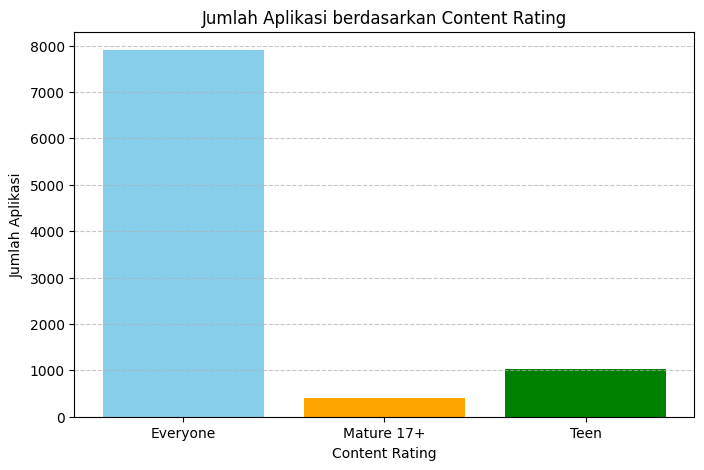

In [103]:
# 4a. Perbandingan jumlah aplikasi berdasarkan Content Rating
import matplotlib.pyplot as plt
filtered_data = data[data['Content_Rating'].isin(['Everyone', 'Teen', 'Mature 17+'])]
content_counts = (filtered_data.groupby('Content_Rating').size().reset_index().rename(columns={0: 'Jumlah Aplikasi'}).compute())
print("Jumlah aplikasi berdasarkan Content Rating (Everyone, Teen, Mature 17+):")
print(content_counts)
# Visualisasi
plt.figure(figsize=(8, 5))
plt.bar(content_counts['Content_Rating'], content_counts['Jumlah Aplikasi'], color=['skyblue', 'orange', 'green'])
plt.title("Jumlah Aplikasi berdasarkan Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Jumlah Aplikasi")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Total jumlah install berdasarkan Content Rating (Everyone, Teen, Mature 17+):
  Content_Rating  Total Install
0       Everyone 52,179,352,961
1     Mature 17+  2,437,986,878
2           Teen 16,487,275,393


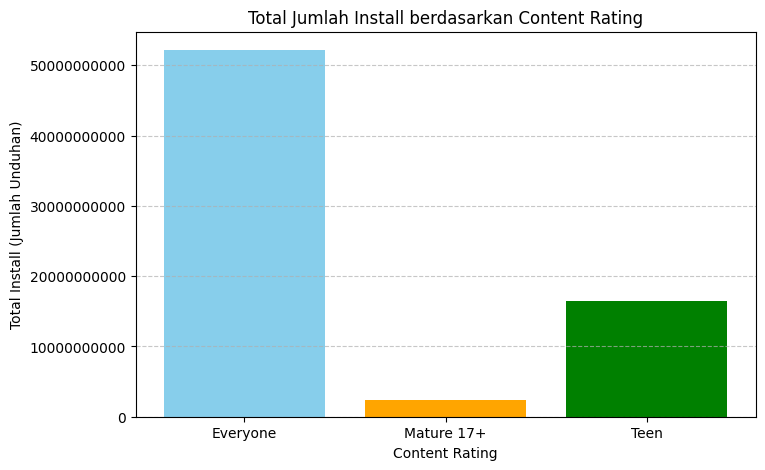

In [104]:
# 4b. Visualisasi Content Rating terhadap jumlah Install
import matplotlib.pyplot as plt
filtered_data = data[data['Content_Rating'].isin(['Everyone', 'Teen', 'Mature 17+'])]
content_installs = (filtered_data.groupby('Content_Rating')['Installs'].sum().reset_index().rename(columns={'Installs': 'Total Install'}).compute())
pd.options.display.float_format = '{:,.0f}'.format
print("Total jumlah install berdasarkan Content Rating (Everyone, Teen, Mature 17+):")
print(content_installs)
pd.reset_option('display.float_format')
# Visualisasi
plt.figure(figsize=(8, 5))
plt.bar(content_installs['Content_Rating'], content_installs['Total Install'], color=['skyblue', 'orange', 'green'])
plt.title("Total Jumlah Install berdasarkan Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Total Install (Jumlah Unduhan)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

10 Aplikasi dengan jumlah Reviews terbanyak:
                                                    App   Reviews
2002                                           Facebook  78158306
300                                  WhatsApp Messenger  69119316
2003                                          Instagram  66577313
299            Messenger – Text and Video Chat for Free  56642847
1372                                     Clash of Clans  44891723
3181            Clean Master- Space Cleaner & Antivirus  42916526
1356                                     Subway Surfers  27722264
2908                                            YouTube  25655305
6486  Security Master - Antivirus, VPN, AppLock, Boo...  24900999
1362                                       Clash Royale  23133508


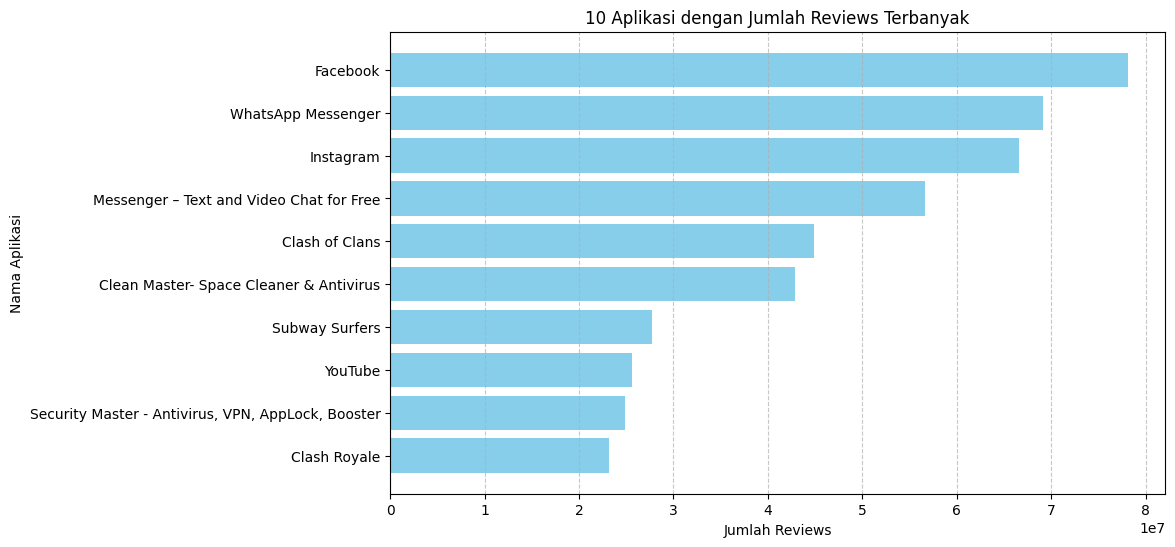

In [105]:
# 5b. 10 Aplikasi dengan jumlah Reviews terbanyak
import matplotlib.pyplot as plt
top_reviews = (data[['App', 'Reviews']].nlargest(10, 'Reviews').compute())
print("10 Aplikasi dengan jumlah Reviews terbanyak:")
print(top_reviews)
# Visualisasi
plt.figure(figsize=(10, 6))
plt.barh(top_reviews['App'], top_reviews['Reviews'], color='skyblue')
plt.title('10 Aplikasi dengan Jumlah Reviews Terbanyak')
plt.xlabel('Jumlah Reviews')
plt.ylabel('Nama Aplikasi')
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [106]:
# 5. Analisis pengaruh Reviews terhadap Rating (tahap awal)
# Pastikan kolom numerik
data['Reviews'] = data['Reviews'].astype(float)
data['Rating'] = data['Rating'].astype(float)

# Tampilkan ringkasan statistik dasar
print("Statistik dasar Reviews dan Rating:")
print(data[['Reviews', 'Rating']].describe().compute())

# Tampilkan 5 aplikasi dengan jumlah Reviews terbanyak
print("\nTop 5 aplikasi dengan jumlah Reviews terbanyak:")
print(data[['App', 'Reviews', 'Rating']].nlargest(5, 'Reviews').compute())


Statistik dasar Reviews dan Rating:
            Reviews       Rating
count  9.659000e+03  9659.000000
mean   2.165926e+05     4.176287
std    1.831320e+06     0.494365
min    0.000000e+00     1.000000
25%    2.500000e+01     4.000000
50%    9.670000e+02     4.200000
75%    2.940100e+04     4.500000
max    7.815831e+07     5.000000

Top 5 aplikasi dengan jumlah Reviews terbanyak:
                                           App     Reviews  Rating
2002                                  Facebook  78158306.0     4.1
300                         WhatsApp Messenger  69119316.0     4.4
2003                                 Instagram  66577313.0     4.5
299   Messenger – Text and Video Chat for Free  56642847.0     4.0
1372                            Clash of Clans  44891723.0     4.6


In [142]:
# 1b. 10 Aplikasi dengan Rating tertinggi 
top10_rating = (data[['App', 'Category', 'Rating']].sort_values(by='Rating', ascending=False).compute().head(10))
print("10 Aplikasi dengan Rating tertinggi:")
print(top10_rating)

10 Aplikasi dengan Rating tertinggi:
                              App            Category  Rating
5266                      BI News  NEWS_AND_MAGAZINES     5.0
5239                   Barbers.BH           LIFESTYLE     5.0
5233             Bh Public School              FAMILY     5.0
5175                     BG Guide    TRAVEL_AND_LOCAL     5.0
5334                     BJ Foods            BUSINESS     5.0
9354           FK CLASSIC FOR YOU            BUSINESS     5.0
9244                    FH School              FAMILY     5.0
9235    Jigsaw Volvo FH 16 Trucks              FAMILY     5.0
9454          Florida Wildflowers              FAMILY     5.0
9446  Florida Beach Wallpapers HD    TRAVEL_AND_LOCAL     5.0


In [114]:
# Ambil 10 rating tertinggi unik
top10_unique_ratings = data[['App','Category','Rating']].dropna(subset=['Rating']).sort_values(by='Rating', ascending=False).drop_duplicates(subset=['Rating']).head(10)
print(top10_unique_ratings)


                                                    App             Category  \
5266                                            BI News   NEWS_AND_MAGAZINES   
5279                       Business Intelligence & Data               FAMILY   
9651                                        Chemin (fr)  BOOKS_AND_REFERENCE   
2     U Launcher Lite – FREE Live Cool Themes, Hide ...       ART_AND_DESIGN   
7388                                     Fodbold DK Pro               SPORTS   
2579                                MyScript Calculator                TOOLS   
8                                  Garden Coloring Book       ART_AND_DESIGN   
3430                                      Lep's World 🍀                 GAME   
9622                                       Poker Pro.Fr                 GAME   
9624                                    SnakeBite911 FR              MEDICAL   

        Rating  
5266  5.000000  
5279  4.900000  
9651  4.800000  
2     4.700000  
7388  4.600000  
2579  4.500000  


In [118]:
# Hitung jumlah aplikasi dengan Rating 5.0
jumlah_rating_5 = data[data['Rating'] == 5.0]['App'].count().compute()
print(f"Jumlah aplikasi dengan Rating 5.0: {jumlah_rating_5}")

Jumlah aplikasi dengan Rating 5.0: 271


In [125]:
# 1b. 10 Aplikasi dengan Rating tertinggi 
top_apps = data[data['Rating'] == 5.0]
top_apps_sorted = top_apps.sort_values(by=['Rating', 'Installs'], ascending=[False, False]).compute()  
top10_apps = top_apps_sorted.head(10)
print("10 Aplikasi dengan Rating 5.0 dan jumlah Install terbanyak:")
print(top10_apps[['App', 'Genres','Rating', 'Installs']])

10 Aplikasi dengan Rating 5.0 dan jumlah Install terbanyak:
                                                   App             Genres  \
8385                          Ek Bander Ne Kholi Dukan      Entertainment   
6464           CL Keyboard - Myanmar Keyboard (No Ads)              Tools   
6993                                        Oración CX          Lifestyle   
7184  Superheroes, Marvel, DC, Comics, TV, Movies News             Comics   
293                       Hojiboy Tojiboyev Life Hacks             Comics   
511                      American Girls Mobile Numbers             Dating   
1259                                      Eternal life   Libraries & Demo   
1988                 BP Journal - Blood Pressure Diary            Medical   
3633                     R Programing Offline Tutorial  Books & Reference   
4114  Tafsiir Quraan MP3 Af Soomaali Quraanka Kariimka          Lifestyle   

      Rating  Installs  
8385     5.0   10000.0  
6464     5.0    5000.0  
6993     5.0    5

In [139]:
# 3b. Korelasi antara genre dan content rating
genre_content = (data.groupby(['Genres', 'Content_Rating']).size().reset_index().compute())
genre_content.columns = ['Genres', 'Content_Rating', 'Jumlah']
total_per_genre = (genre_content.groupby('Genres')['Jumlah'].sum().sort_values(ascending=False).head(10).index)
genre_top = genre_content[genre_content['Genres'].isin(total_per_genre)]
print(genre_top.head(10))

            Genres Content_Rating  Jumlah
46        Business       Everyone     405
47        Business   Everyone 10+       1
48        Business     Mature 17+       1
49        Business           Teen      13
80       Education       Everyone     484
81       Education   Everyone 10+       6
82       Education     Mature 17+       5
83       Education           Teen      15
99   Entertainment       Everyone     375
100  Entertainment   Everyone 10+       7


In [131]:
jumlah_genre = data['Genres'].nunique().compute()
print("Jumlah kelas (kategori) Genre:", jumlah_genre)


Jumlah kelas (kategori) Genre: 118


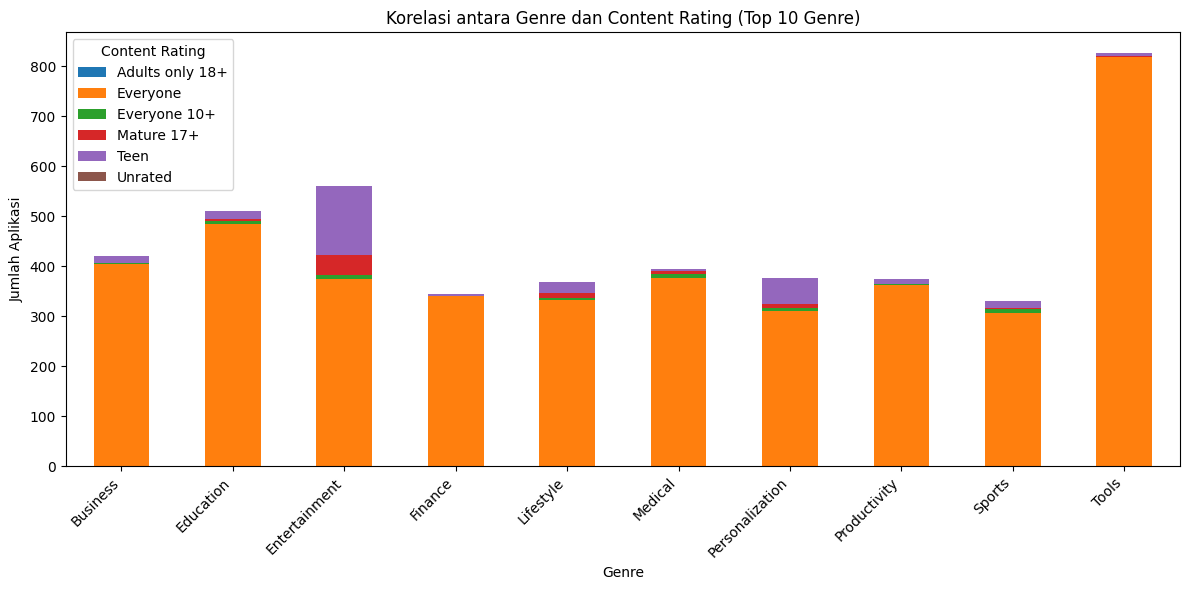

In [137]:
import matplotlib.pyplot as plt

# Langkah 1: hitung jumlah aplikasi per Genre dan Content Rating
genre_content = (
    data.groupby(['Genres', 'Content_Rating'])
    .size()
    .reset_index()
    .compute()
)

# Langkah 2: ubah nama kolom agar lebih jelas
genre_content.columns = ['Genres', 'Content_Rating', 'Jumlah']

# Langkah 3: ambil 10 Genre dengan jumlah aplikasi terbanyak
top_genres = (
    genre_content.groupby('Genres')['Jumlah']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

genre_top = genre_content[genre_content['Genres'].isin(top_genres)]

# Langkah 4: pivot untuk keperluan visualisasi
pivot_data = genre_top.pivot_table(index='Genres', columns='Content_Rating', values='Jumlah', fill_value=0)

# Langkah 5: buat diagram batang bertumpuk
pivot_data.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title('Korelasi antara Genre dan Content Rating (Top 10 Genre)')
plt.xlabel('Genre')
plt.ylabel('Jumlah Aplikasi')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Content Rating')
plt.tight_layout()
plt.show()


10 Aplikasi dengan jumlah Reviews terbanyak:
                                                    App     Reviews
2002                                           Facebook  78158306.0
300                                  WhatsApp Messenger  69119316.0
2003                                          Instagram  66577313.0
299            Messenger – Text and Video Chat for Free  56642847.0
1372                                     Clash of Clans  44891723.0
3181            Clean Master- Space Cleaner & Antivirus  42916526.0
1356                                     Subway Surfers  27722264.0
2908                                            YouTube  25655305.0
6486  Security Master - Antivirus, VPN, AppLock, Boo...  24900999.0
1362                                       Clash Royale  23133508.0


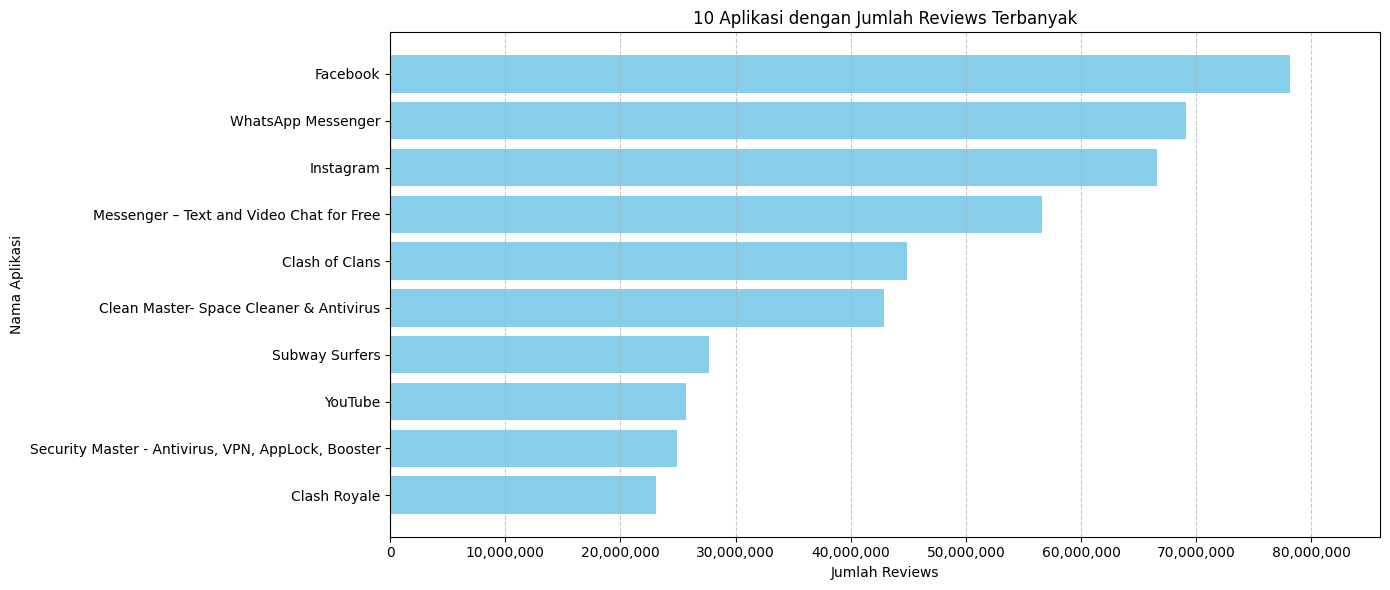

In [146]:
# 5b. 10 Aplikasi dengan jumlah Reviews terbanyak
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
top_reviews = (data[['App', 'Reviews']].nlargest(10, 'Reviews').compute())
print("10 Aplikasi dengan jumlah Reviews terbanyak:")
print(top_reviews)
# Visualisasi hasilnya
plt.figure(figsize=(14, 6))
plt.barh(top_reviews['App'], top_reviews['Reviews'], color='skyblue')
plt.title('10 Aplikasi dengan Jumlah Reviews Terbanyak')
plt.xlabel('Jumlah Reviews')
plt.ylabel('Nama Aplikasi')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xlim(0, top_reviews['Reviews'].max() * 1.1)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

10 Aplikasi dengan Jumlah Reviews Terbanyak dan Rating-nya:
                                                    App     Reviews  Rating
2002                                           Facebook  78158306.0     4.1
300                                  WhatsApp Messenger  69119316.0     4.4
2003                                          Instagram  66577313.0     4.5
299            Messenger – Text and Video Chat for Free  56642847.0     4.0
1372                                     Clash of Clans  44891723.0     4.6
3181            Clean Master- Space Cleaner & Antivirus  42916526.0     4.7
1356                                     Subway Surfers  27722264.0     4.5
2908                                            YouTube  25655305.0     4.3
6486  Security Master - Antivirus, VPN, AppLock, Boo...  24900999.0     4.7
1362                                       Clash Royale  23133508.0     4.6


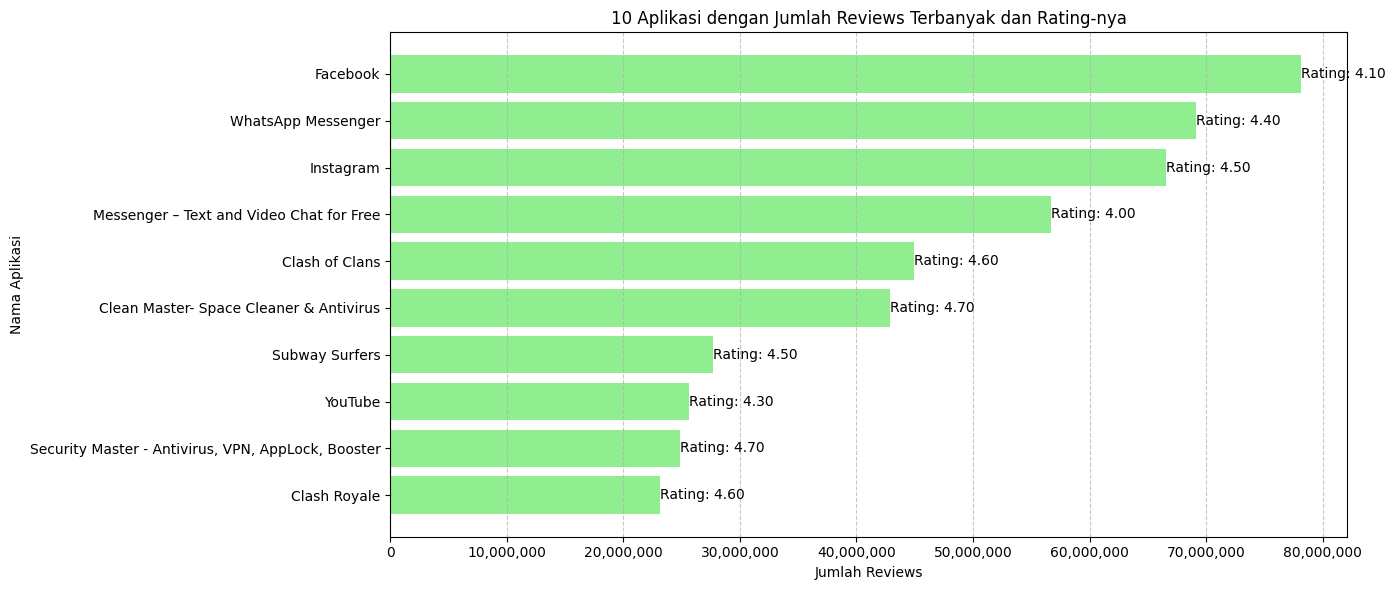

In [162]:
# 5a. Pengaruh Reviews terhadap Rating
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
top_reviews_rating = data[['App', 'Reviews', 'Rating']].nlargest(10, 'Reviews').compute()
print("10 Aplikasi dengan Jumlah Reviews Terbanyak dan Rating-nya:")
print(top_reviews_rating)
# Visualisasi
plt.figure(figsize=(14, 6))
plt.barh(top_reviews_rating['App'], top_reviews_rating['Reviews'], color='lightgreen')
plt.title('10 Aplikasi dengan Jumlah Reviews Terbanyak dan Rating-nya')
plt.xlabel('Jumlah Reviews')
plt.ylabel('Nama Aplikasi')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.gca().invert_yaxis()
for i, (app, reviews, rating) in enumerate(zip(top_reviews_rating['App'], top_reviews_rating['Reviews'], top_reviews_rating['Rating'])):
    plt.text(reviews, i, f'Rating: {rating:.2f}', va='center')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()